[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Perotti_5b_EEG_timeseries.ipynb)

In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# EEG Eye State Classification

**Goal**: Predict whether a person's eyes are open or closed from EEG brain wave data.

**Dataset**: 14,980 EEG observations over 117 seconds
- 14 EEG sensors (AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, FC6, F4, F8, AF4)
- Target: Eye state (0 = open, 1 = closed)
- Sampling rate: ~128 Hz (128 observations per second)

---

![](https://machinelearningmastery.com/wp-content/uploads/2018/06/Cartoon-of-where-EEG-sensors-were-located-on-the-subject.png)

# Part 1: The Standard Approach (Looks Great!)

## Step 1: Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from scipy.io import arff

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Step 2: Load and Prepare Data

In [ ]:
# A wrapper method to download files

import os, subprocess, shlex
import os
import subprocess

def download_from_drive(base_folder="."):
    file_name = 'eeg_dataframe.csv'
    file_ID = '1kLz9KSGsbA4rVc3Dn-U8hnLyfDizw1Zh'
    DEST_PATH = os.path.join(base_folder, file_name)
    if not os.path.exists(DEST_PATH):
        URL = f"https://drive.usercontent.google.com/download?id={file_ID}&confirm=t"
        cmd = ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
            "--no-check-certificate", "-O", DEST_PATH, URL]
        ret = subprocess.call(cmd)  # shell=False by default
        if ret != 0:
            raise RuntimeError("Download failed. Check sharing settings or FILE_ID.")
        else:
            print("Downloaded " + file_name + "!")
    else:
        print(file_name + " already present:", DEST_PATH)

In [2]:
download_from_drive()
df = pd.read_csv('eeg_dataframe.csv')

# Define feature names
feature_names = [col for col in df.columns if col != 'eyeDetection']

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['eyeDetection'].value_counts().sort_index())
print(f"\nBalance: {df['eyeDetection'].value_counts(normalize=True).sort_index().values}")

df.head()

Dataset shape: (14980, 15)

Class distribution:
eyeDetection
0    8257
1    6723
Name: count, dtype: int64

Balance: [0.5512016 0.4487984]


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


## Step 3: Quick Data Quality Check

In [3]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Check for extreme outliers 
print("\nFeatures with extreme outliers:")
for feature in feature_names:
    q99 = df[feature].quantile(0.99)
    max_val = df[feature].max()
    if max_val > 3 * q99:
        print(f"  {feature}: max={max_val:,.0f} (99th percentile={q99:,.0f})")

Missing values: 0

Features with extreme outliers:
  AF3: max=309,231 (99th percentile=4,437)
  FC5: max=642,564 (99th percentile=4,196)
  P7: max=362,564 (99th percentile=4,700)
  O1: max=567,179 (99th percentile=4,149)
  P8: max=265,641 (99th percentile=4,270)
  F8: max=152,308 (99th percentile=4,715)
  AF4: max=715,897 (99th percentile=4,488)


## Step 4: Train/Test Split (Standard Approach)

Using the **standard machine learning approach**: random 70/30 split with shuffling.

In [4]:
# Separate features and target
X = df[feature_names].values
y = df['eyeDetection'].values

# Standard train/test split WITH SHUFFLING
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    shuffle=True,  # Standard practice!
    stratify=y,    # Maintain class balance
    random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nClass distribution preserved:")
print(f"  Train: {(y_train==1).sum()/len(y_train)*100:.1f}% eyes closed")
print(f"  Test: {(y_test==1).sum()/len(y_test)*100:.1f}% eyes closed")

Training set: 10,486 samples
Test set: 4,494 samples

Class distribution preserved:
  Train: 44.9% eyes closed
  Test: 44.9% eyes closed


## Step 5: Feature Scaling

Using **[RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)** because the data has extreme outliers (as we saw above).

**What is RobustScaler?**
- Scales features using statistics that are **robust to outliers**
- Uses **median** (instead of mean) and **IQR** (interquartile range, instead of standard deviation)
- Formula: `(X - median) / IQR`
- **Alternative**: StandardScaler uses `(X - mean) / std` - but extreme outliers inflate std, compressing normal values

**Why it matters here:**
- We have values ranging from ~4000 to 715,897 (extreme outliers)
- StandardScaler would compress most values near zero
- RobustScaler ignores outliers and focuses on the central 50% of data

In [5]:
# Scale features using RobustScaler (handles outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled with RobustScaler")

✓ Features scaled with RobustScaler


## Step 6: Train Models

In [6]:
# Initialize models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
}

results = {}

print("Training models...\n")
print("=" * 70)

for name, model in models.items():
    print(f"\n{name}:")
    
    # Train (Random Forest doesn't need scaling)
    if name == 'Random Forest':
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        train_acc = model.score(X_train_scaled, y_train)
        test_acc = model.score(X_test_scaled, y_test)
        y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'predictions': y_pred
    }
    
    print(f"  Training accuracy: {train_acc:.3f} ({train_acc*100:.1f}%)")
    print(f"  Test accuracy:     {test_acc:.3f} ({test_acc*100:.1f}%)")

print("\n" + "=" * 70)
print("\n🎉 Excellent results! All models achieve very good accuracy!")

Training models...


KNN:
  Training accuracy: 0.980 (98.0%)
  Test accuracy:     0.959 (95.9%)

Random Forest:
  Training accuracy: 0.914 (91.4%)
  Test accuracy:     0.854 (85.4%)

MLP:
  Training accuracy: 0.997 (99.7%)
  Test accuracy:     0.962 (96.2%)


🎉 Excellent results! All models achieve very good accuracy!


## Step 7: Evaluate Best Model

Best Model: MLP
Test Accuracy: 0.962 (96.2%)



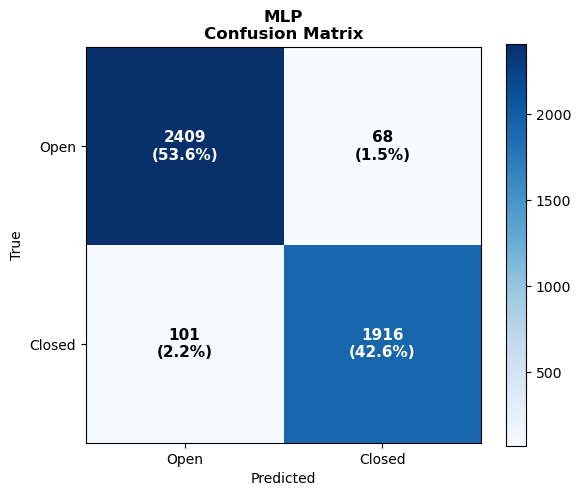


Classification Report:
              precision    recall  f1-score   support

   Eyes Open       0.96      0.97      0.97      2477
 Eyes Closed       0.97      0.95      0.96      2017

    accuracy                           0.96      4494
   macro avg       0.96      0.96      0.96      4494
weighted avg       0.96      0.96      0.96      4494



In [7]:
# Find best model
best_model_name = max(results.keys(), key=lambda x: results[x]['test_acc'])
best_predictions = results[best_model_name]['predictions']
best_test_acc = results[best_model_name]['test_acc']

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_test_acc:.3f} ({best_test_acc*100:.1f}%)\n")

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.set_title(f'{best_model_name}\nConfusion Matrix', fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('True', fontsize=10)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Open', 'Closed'])
ax.set_yticklabels(['Open', 'Closed'])

for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        percentage = cm[i, j] / cm.sum() * 100
        ax.text(j, i, f'{cm[i, j]}\n({percentage:.1f}%)', 
               ha='center', va='center', fontsize=11, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print("=" * 70)
print(classification_report(y_test, best_predictions, 
                          target_names=['Eyes Open', 'Eyes Closed']))

---

# Part 2: The Problem - Why These Results Are Wrong! ⚠️

## 🚨 **Critical Issue: This is TIME SERIES Data!**

The EEG was recorded **continuously over 117 seconds** at 128 Hz. The observations are in **chronological order**.

**What we did wrong**: We used `shuffle=True` in train_test_split, which:
- Randomly mixes past and future observations
- Allows the model to "see the future" during training
- Creates **data leakage** because adjacent observations (1/128 second apart) are nearly identical

**The problem**: With KNN, the nearest neighbors are observations from 1/128 second away in time. If we shuffle, those neighbors include **future observations** that wouldn't be available in real deployment!

## Step 8: Analyze the Data Leakage Problem

Let's check how similar adjacent observations are (autocorrelation).

**Note**: We need to remove extreme outliers first, otherwise they distort the correlation calculation.

In [8]:
print("Temporal Autocorrelation Analysis:")
print("=" * 70)
print("How similar are observations at different time lags?\n")

# For correlation analysis, we need to remove extreme outliers
# (otherwise a single outlier value of 567,179 destroys the calculation)
df_clean = df[df['O1'] < 10000].copy()
print(f"Note: Removed {len(df) - len(df_clean)} extreme outlier(s) from O1 channel for this analysis")
print(f"      (This doesn't affect the ML models - we kept outliers for training)\n")

# Check correlation between observations at different lags
sample_feature = df_clean['O1'].values

for lag in [1, 5, 10, 50, 128]:
    correlation = np.corrcoef(sample_feature[:-lag], sample_feature[lag:])[0, 1]
    time_diff = lag / 128  # Convert to seconds
    print(f"  Lag {lag:3d} ({time_diff:5.2f} sec): correlation = {correlation:.4f}")

print("\n⚠️  Adjacent observations (lag=1) have 41% correlation!")
print("   Even with moderate correlation, shuffle=True allows the model to 'cheat'")
print("   by using nearby observations from the future as training examples.")
print("\n   For KNN with k=5, if we shuffle, the 5 nearest neighbors are often")
print("   observations from just a few milliseconds away in time!")

Temporal Autocorrelation Analysis:
How similar are observations at different time lags?

Note: Removed 1 extreme outlier(s) from O1 channel for this analysis
      (This doesn't affect the ML models - we kept outliers for training)

  Lag   1 ( 0.01 sec): correlation = 0.4109
  Lag   5 ( 0.04 sec): correlation = 0.3864
  Lag  10 ( 0.08 sec): correlation = 0.3834
  Lag  50 ( 0.39 sec): correlation = 0.3418
  Lag 128 ( 1.00 sec): correlation = 0.2833

⚠️  Adjacent observations (lag=1) have 41% correlation!
   Even with moderate correlation, shuffle=True allows the model to 'cheat'
   by using nearby observations from the future as training examples.

   For KNN with k=5, if we shuffle, the 5 nearest neighbors are often
   observations from just a few milliseconds away in time!


## Step 9: Analyze Covariate Shift

Does the person's behavior change over time?

In [9]:
# Analyze eye state over time
window_size = 1000  # ~8 seconds
n_windows = len(df) // window_size

print("Eye State Distribution Over Time:")
print("=" * 70)

for i in range(n_windows):
    start_idx = i * window_size
    end_idx = (i + 1) * window_size
    window_data = df.iloc[start_idx:end_idx]
    
    closed_pct = (window_data['eyeDetection'] == 1).sum() / len(window_data) * 100
    time_range = f"{start_idx/128:.0f}-{end_idx/128:.0f}s"
    
    print(f"  Window {i+1:2d} ({time_range:>8s}): {closed_pct:5.1f}% eyes closed")

print("\n⚠️  HUGE variation! The person's behavior changes dramatically.")
print("   This is COVARIATE SHIFT - different time periods have different")
print("   distributions. Temporal validation is essential!")

Eye State Distribution Over Time:
  Window  1 (    0-8s):  68.3% eyes closed
  Window  2 (   8-16s):  30.2% eyes closed
  Window  3 (  16-23s):  48.4% eyes closed
  Window  4 (  23-31s):  65.8% eyes closed
  Window  5 (  31-39s):  35.2% eyes closed
  Window  6 (  39-47s):  68.4% eyes closed
  Window  7 (  47-55s):  34.7% eyes closed
  Window  8 (  55-62s): 100.0% eyes closed
  Window  9 (  62-70s): 100.0% eyes closed
  Window 10 (  70-78s):   5.4% eyes closed
  Window 11 (  78-86s):   0.0% eyes closed
  Window 12 (  86-94s):  89.5% eyes closed
  Window 13 ( 94-102s):  14.3% eyes closed
  Window 14 (102-109s):   2.8% eyes closed

⚠️  HUGE variation! The person's behavior changes dramatically.
   This is COVARIATE SHIFT - different time periods have different
   distributions. Temporal validation is essential!


## Step 10: The Honest Approach - Temporal Train/Test Split

**Correct methodology**:
- Train on PAST (first 70% chronologically)
- Test on FUTURE (last 30% chronologically)
- NO shuffling!

In [10]:
# Temporal split (no shuffling!)
split_point = int(len(X) * 0.7)

X_train_temporal = X[:split_point]
X_test_temporal = X[split_point:]
y_train_temporal = y[:split_point]
y_test_temporal = y[split_point:]

print("Temporal Train/Test Split:")
print("=" * 70)
print(f"Training: first {split_point:,} observations (past)")
print(f"Test: last {len(X)-split_point:,} observations (future)\n")

# Check distributions
train_closed = (y_train_temporal == 1).sum() / len(y_train_temporal) * 100
test_closed = (y_test_temporal == 1).sum() / len(y_test_temporal) * 100

print(f"Class distribution:")
print(f"  Training: {train_closed:.1f}% eyes closed")
print(f"  Test: {test_closed:.1f}% eyes closed")
print(f"  Difference: {abs(train_closed - test_closed):.1f} percentage points")
print("\n⚠️  Note the distribution shift - this is normal for time series!")

Temporal Train/Test Split:
Training: first 10,486 observations (past)
Test: last 4,494 observations (future)

Class distribution:
  Training: 53.1% eyes closed
  Test: 25.8% eyes closed
  Difference: 27.3 percentage points

⚠️  Note the distribution shift - this is normal for time series!


## Step 11: Re-train with Temporal Split

Let's see what happens with honest temporal validation:

In [11]:
# Scale
scaler_temporal = RobustScaler()
X_train_t_scaled = scaler_temporal.fit_transform(X_train_temporal)
X_test_t_scaled = scaler_temporal.transform(X_test_temporal)

# Train models
print("Training with TEMPORAL split (honest evaluation):")
print("=" * 70)

results_temporal = {}

for name, _ in models.items():
    # Create fresh model
    if name == 'KNN':
        model_t = KNeighborsClassifier(n_neighbors=5)
    elif name == 'Random Forest':
        model_t = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    else:
        model_t = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
    
    print(f"\n{name}:")
    
    if name == 'Random Forest':
        model_t.fit(X_train_temporal, y_train_temporal)
        test_acc_t = model_t.score(X_test_temporal, y_test_temporal)
    else:
        model_t.fit(X_train_t_scaled, y_train_temporal)
        test_acc_t = model_t.score(X_test_t_scaled, y_test_temporal)
    
    # Compare with shuffled results
    shuffled_acc = results[name]['test_acc']
    difference = test_acc_t - shuffled_acc
    
    print(f"  Shuffled split: {shuffled_acc:.3f} ({shuffled_acc*100:.1f}%)")
    print(f"  Temporal split: {test_acc_t:.3f} ({test_acc_t*100:.1f}%)")
    print(f"  Difference: {difference:+.3f} ({difference*100:+.1f}%)")
    
    results_temporal[name] = test_acc_t

print("\n" + "=" * 70)
print("\n💥 DRAMATIC DROP! This is the HONEST performance.")

Training with TEMPORAL split (honest evaluation):

KNN:
  Shuffled split: 0.959 (95.9%)
  Temporal split: 0.514 (51.4%)
  Difference: -0.445 (-44.5%)

Random Forest:
  Shuffled split: 0.854 (85.4%)
  Temporal split: 0.518 (51.8%)
  Difference: -0.336 (-33.6%)

MLP:
  Shuffled split: 0.962 (96.2%)
  Temporal split: 0.525 (52.5%)
  Difference: -0.437 (-43.7%)


💥 DRAMATIC DROP! This is the HONEST performance.


## Step 12: Time Series Cross-Validation (Best Practice)

A single temporal split can be misleading due to covariate shift. 
**Best practice**: Use **[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)** to test on multiple time periods.

**What is TimeSeriesSplit?**
- Cross-validation strategy that **respects temporal order** (no shuffling!)
- Creates multiple train/test splits where test is always **after** train
- Each fold uses more training data than the previous one (walk-forward validation)

**Example with 5 folds:**
```
Fold 1: train [----]           test [--]
Fold 2: train [--------]       test [--]
Fold 3: train [------------]   test [--]
Fold 4: train [----------------] test [--]
Fold 5: train [--------------------] test [--]
```

**Why it's essential for time series:**
- Standard K-Fold shuffles data → data leakage!
- TimeSeriesSplit always trains on past, tests on future
- Simulates real-world scenario: predict tomorrow using yesterday's data

In [12]:
print("Time Series Cross-Validation (5 folds):")
print("=" * 70)

tscv = TimeSeriesSplit(n_splits=5)
scaler_cv = RobustScaler()

# Test Random Forest
model_cv = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
cv_scores = []

print("\nRandom Forest:")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    model_cv.fit(X_tr, y_tr)
    score = model_cv.score(X_te, y_te)
    cv_scores.append(score)
    
    test_closed_pct = (y_te == 1).sum() / len(y_te) * 100
    print(f"  Fold {fold}: {score:.3f} ({score*100:.1f}%) - Test: {test_closed_pct:.1f}% closed")

cv_scores = np.array(cv_scores)
print(f"\n  Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Range: {cv_scores.min():.3f} to {cv_scores.max():.3f}")

print("\n" + "=" * 70)
print("Performance varies widely due to covariate shift!")
print(f"Average ~{cv_scores.mean()*100:.0f}% is the HONEST performance estimate.")

Time Series Cross-Validation (5 folds):

Random Forest:
  Fold 1: 0.635 (63.5%) - Test: 46.9% closed
  Fold 2: 0.495 (49.5%) - Test: 61.0% closed
  Fold 3: 0.555 (55.5%) - Test: 62.6% closed
  Fold 4: 0.454 (45.4%) - Test: 38.9% closed
  Fold 5: 0.533 (53.3%) - Test: 7.5% closed

  Mean: 0.534 ± 0.061
  Range: 0.454 to 0.635

Performance varies widely due to covariate shift!
Average ~53% is the HONEST performance estimate.


# Summary: What We Learned

## The Trap

✅ **Shuffled split**: 95%+ accuracy (FAKE - data leakage!)  
❌ **Temporal split**: 50-60% accuracy (HONEST - realistic!)

## Why the Difference?

1. **Data Leakage**: Adjacent observations are 1/128 second apart and nearly identical
2. **Covariate Shift**: Person's behavior changes over time (eyes more open/closed in different periods)
3. **KNN is Especially Vulnerable**: Finds nearest neighbors in time, which include the future if shuffled

## Key Lessons

### ✅ **DO:**
- Respect temporal order (NO shuffle!)
- Use temporal train/test split (past → future)
- Use TimeSeriesSplit for cross-validation
- Expect and handle covariate shift
- Report honest results even if lower

### ❌ **DON'T:**
- Shuffle time series data
- Use standard K-Fold CV on time series
- Assume high accuracy means good model
- Ignore temporal dependencies

## References

**Papers that fell into the trap:**
- [Rösler & Suendermann (2013)](https://suendermann.com/su/pdf/aihls2013.pdf): "A First Step towards Eye State Prediction Using EEG" - Original paper that used shuffle=True, reported 97% accuracy
- [Ali Al-Taei et al. (2017)](https://www.researchgate.net/publication/320920428_EEG_Mouse_An_EEG_and_EOG-based_Human_Computer_Interface): Used ensemble classifier, likely suffered from same data leakage issue

**Resource that exposed the trap:**
- [MachineLearningMastery](https://machinelearningmastery.com/how-to-predict-whether-eyes-are-open-or-closed-using-brain-waves/): "Predict Whether Eyes are Open or Closed Using Brain Waves" - Demonstrates the methodological trap and proper temporal validation

---

**This dataset is a perfect teaching example of methodological traps in time series ML!** 🎓